#**PLEASE SAVE A COPY OF THIS NOTEBOOK TO SUBMIT**

# Modeling: MultiModal AI — Homework 4
**MAS.S60 / 6.S985 • Spring 2026 • MIT**

In this homework, you will explore **Reinforcement Learning for Vision-Language Models**. Specifically, you will implement and train a VLM using **Group Relative Policy Optimization (GRPO)**, a recent RL algorithm for aligning language models with reward signals.

---

## Environment Setup

Go to the top menu:
Runtime → Change runtime type → Hardware accelerator → Choose **"A100"**

If you do not have Colab Pro, you can sign up for a free student Colab Pro account here:
https://colab.research.google.com/signup

# Part 1: Reading & Reflection (20 points)

### Required Reading

1. [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300) (Sections 1, 3, and 4)

2. [The Illustrated GRPO](https://abderrahmanskiredj.github.io/the-illustrated-grpo/) (Full post)

---

### Questions

1. **GRPO vs PPO**: GRPO removes the need for a learned value function (critic). Explain how GRPO estimates the baseline for advantage computation without a critic, and what tradeoffs this introduces.

    GRPO no longer relies on an exteral "teacher" (critic model) to score, instead it uses: generating a set of answers based on the same question, and directly using the average scores of these answers as a baseline, those who perform better than the average score would be seen that they have positive "advantage", the trade-off inherent in this approach is as follow: while by eliminating the critic model, it significantly reduces memory consumption(by approximately 50%) and thereby lowers training costs, it imposes higer demands on sampling volume. furthermore, due to the absence of predictive criteria, the model is highly susceptible to flaws in the reward function, which can lead to cheating behaviors.

2. **Reward Design**: Discuss the difference between using a learned reward model vs. a rule-based reward function (e.g., checking if an answer matches ground truth). What are the risks of reward hacking in each case?

    Reward Design: Learned RM vs. Rule-Based RF

    Learned Reward Model (RM): A neural network that mimics human judgment to score abstract qualities like "helpfulness" or "tone."

      Risk: Adversarial Exploitation. The model may discover "cheat codes"—specific phrases or formatting quirks—that trick the RM into giving high scores even if the logic is wrong.

    Rule-Based Reward Function (RF): Hard-coded logic (e.g., Regular Expressions) that checks objective truths, such as whether a math answer matches the ground truth.

      Risk: Format Hacking. The model might "guess" the final answer or generate meaningless, repetitive reasoning chains just to satisfy the rules and trigger the reward.

    Learned RMs are flexible but prone to sycophancy (telling the judge what it wants to hear), while Rule-Based RFs are objective but prone to mechanical cheating (gaming the specific rules). Most advanced systems use a mix of both, stabilized by a KL Divergence penalty to keep the model from drifting into these "hacking" behaviors  

3. **SFT vs. GRPO**: In Homework 3, you fine-tuned a VLM using supervised fine-tuning (SFT) with LoRA. Compare the SFT approach with GRPO training: how does the training signal differ, and when would each be preferred?


    SFT (Supervised Fine-Tuning): Deterministic Imitation
      * **Signal:** The training signal is a static, predefined target (Ground Truth) provided by human annotators.
      * **Mechanism:** It utilizes Cross-Entropy Loss for next-token prediction. The model is explicitly told what the exact sequence of words should be.
      * **Nature:** It is essentially imitation learning. The model learns the distribution and format of the data (like "how to speak") but does not autonomously verify the correctness of the underlying logic.
      
    GRPO (Group Relative Policy Optimization): Relative Exploration
      * **Signal:** The training signal is a scalar score provided by a reward function (either rule-based or a learned model).
      * **Mechanism:** It relies on Policy Gradients. The model generates a group of different outputs for the same prompt, and the training signal is the calculated advantage.
      * **Nature:** It is trial-and-error optimization. The model does not know the perfect answer beforehand; it explores various reasoning paths and increases the probability of generating sequences that yield higher-than-average rewards.

    and when to use SFT
      * **Foundational Alignment:** When building basic conversational capabilities, defining output templates, or setting the model's tone.
      * **Low-Cost Annotation Tasks:** For tasks where high-quality standard answers are easy and cheap for humans to produce.
      * **Need for Stability:** When you require a stable, mathematically deterministic convergence process. SFT is generally less resource-intensive regarding inference computation and serves as the necessary prerequisite stage before reinforcement learning.

    when to use GRPO
      * **Pushing Limits in Reasoning Tasks:** For domains like mathematics or coding, where intermediate reasoning paths are infinitely varied and too expensive to annotate, but the final outcome is easily verifiable.
      * **Self-Exploration Beyond Human Data:** When SFT has reached the bottleneck of human expertise, and you need the model to discover novel or more efficient solutions on its own.
      * **Memory-Constrained Environments:** Because GRPO eliminates the Critic model used in standard PPO, it significantly reduces GPU memory usage during training. It is highly suitable when you are willing to trade increased inference computation for reduced training memory overhead.

# Part 2: Implementing and Training GRPO (100 points)

# Problem 1: GPU Verification and Library Installation

Run the following code cell to verify that your environment is correctly configured.

This step ensures that **PyTorch** and **CUDA** can access the GPU.
When the setup is correct, a **secret word** will appear in the output.

---

### In Your PDF Submission

Include:
- A **screenshot** or **code snippet** showing the printed GPU information.
- The **secret word** displayed by your verification cell.

---

In [ ]:
!pip install transformers accelerate bitsandbytes pillow torch torchvision trl peft datasets gdown qwen-vl-utils -q

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t = torch.randn(2, 3, device=device)
KEY = 73
cipher_bytes = [14, 27, 25, 6, 105, 32, 58, 105, 8, 37, 37, 105, 16, 38, 60, 105, 7, 44, 44, 45]

if t.is_cuda:
    cipher = torch.tensor(cipher_bytes, dtype=torch.uint8, device=device)
    decoded = cipher ^ KEY
    secret_word = "".join(chr(c) for c in decoded.cpu().tolist())
    print(f"\nGPU check passed! Secret word: {secret_word}")
else:
    print("\nNo GPU detected. Please switch to an A100 runtime.")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA device count: 1
GPU name: NVIDIA A100-SXM4-40GB

GPU check passed! Secret word: GRPO is All You Need


# Problem 2: Prepare Your Dataset (10 points)

You will **reuse the dataset you prepared in Homework 3** (or Homework 1/2). The data format remains the same:

```
mmai-data/
├── images/
│   ├── image_01.jpg
│   └── ...
└── data.jsonl
```

Each line in `data.jsonl` should be a JSON object with:

```json
{
  "image": "images/1.jpg",
  "question": "What animal is in this image?",
  "answer": "cat"
}
```

**If you do not have your own dataset**, the default Google Drive link below will download a small example dataset so you can complete the homework. You will lose some points for not using your own data, but you can still finish every problem.

As in HW3, you should have a **train/test split**. The test images should not be used during training.

In HW3, you used supervised fine-tuning (SFT), which directly trains the model to produce the correct answer. In this homework, we use **reinforcement learning**: the model generates its own answers, receives a reward signal, and updates its policy to maximize future reward.

To enable the RL training loop, we append an instruction after each user question asking the model to **think step-by-step** and then place its final answer after `Answer:`. This structured output lets us automatically extract and evaluate the model's prediction.

In [ ]:
import os, shutil, zipfile, json
from pathlib import Path

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================
# Upload your dataset as a zip file to Google Drive, then
# replace the URL below with your own Google Drive share link.
#
# If you do not have your own dataset, leave the default URL.
# The default dataset is a small example so you can still
# complete the homework.

GDRIVE_SHARE_URL: str = "https://drive.google.com/file/d/1Se8EsgNBqez_NoO9QHkMSqyOkm8jqFQP/view?usp=drive_link"

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

DATA_ROOT = Path("mmai-data")
ZIP_PATH  = Path("mmai-data.zip")

if not DATA_ROOT.exists():
    if GDRIVE_SHARE_URL:
        import gdown
        gdown.download(GDRIVE_SHARE_URL, str(ZIP_PATH), quiet=False, fuzzy=True)
        with zipfile.ZipFile(ZIP_PATH) as zf:
            zf.extractall(".")
        ZIP_PATH.unlink(missing_ok=True)
    else:
        print("Please set GDRIVE_SHARE_URL above, or manually upload mmai-data/ folder.")

# Verify dataset
if DATA_ROOT.exists():
    jsonl_path = DATA_ROOT / "data.jsonl"
    with open(jsonl_path) as f:
        lines = [json.loads(l) for l in f if l.strip()]
    print(f"Dataset loaded: {len(lines)} samples")
    print(f"Sample: {lines[0]}")
else:
    print("Dataset not found. Please upload your data.")

Dataset loaded: 112 samples
Sample: {'image': 'images/a12_s1_t1.jpg', 'question': 'What action is the person performing in this image?', 'answer': 'bowling'}


# Problem 3: Understanding GRPO (15 points)

Before implementing GRPO, let us walk through the key ideas.

## Background: From PPO to GRPO

Standard RLHF methods like **PPO (Proximal Policy Optimization)** require four models: a policy, a reference model, a reward model, and a value model (critic). GRPO simplifies this by **removing the value model entirely**, using the group of completions generated for the same prompt to estimate a baseline.

## The GRPO Algorithm

Given a prompt $q$, we sample $G$ completions $\{o_1, o_2, \ldots, o_G\}$ from the current policy $\pi_\theta$. Each completion receives a reward $r_i$.

### Step 1: Compute the Group Advantage

$$\hat{A}_i = \frac{r_i - \text{mean}(\mathbf{r})}{\text{std}(\mathbf{r}) + \epsilon}$$

where $\mathbf{r} = [r_1, \ldots, r_G]$ are the rewards for all completions of the same prompt.

### Step 2: Clipped Surrogate Loss

$$L_{\text{GRPO}}(\theta) = -\frac{1}{G} \sum_{i=1}^{G} \frac{1}{|o_i|} \sum_{t=1}^{|o_i|} \min\left( \rho_{i,t} \hat{A}_i,\ \text{clip}(\rho_{i,t},\ 1 - \varepsilon,\ 1 + \varepsilon) \hat{A}_i \right)$$

where $\rho_{i,t} = \frac{\pi_\theta(o_{i,t} | q, o_{i,<t})}{\pi_{\theta_{\text{old}}}(o_{i,t} | q, o_{i,<t})}$ is the importance sampling ratio.

### Step 3 (Optional): KL Regularization

$$L_{\text{total}} = L_{\text{GRPO}} + \beta \cdot \mathbb{D}_{\text{KL}}[\pi_\theta \| \pi_{\text{ref}}]$$

---

## Questions to Answer:

1. In your own words, explain why the group-based advantage normalization works as a baseline. What happens when all $G$ completions for a prompt receive the same reward?

    GRPO skips the value model entirely. Instead of training a separate critic to estimate a baseline, it just samples GG
    G completions for the same prompt and uses their mean reward as the baseline. Each completion's advantage is simply how much better or worse it did compared to the group average, normalized by the standard deviation to keep gradient scales consistent. It's a straightforward Monte Carlo estimate of expected return.

    When all GG
    G completions receive the same reward, the difference from the mean is zero for every one of them, and the standard deviation is also zero, so all advantages become zero. That prompt contributes nothing to the gradient update. This makes sense — if every sampled output is equally good or bad, there's no signal to learn from.

2. What is the role of the clipping term $\text{clip}(\rho_{i,t}, 1-\varepsilon, 1+\varepsilon)$? What could go wrong during training without it?

    The clip term limits how much the policy can change in a single update. The importance sampling ratio ρi,t\rho_{i,t}
    ρi,t​ measures how much the new policy's probability on a token differs from the old policy's. Clipping it to [1−ε,1+ε][1-\varepsilon, 1+\varepsilon]
    [1−ε,1+ε] and taking the min⁡\min
    min with the unclipped objective creates a conservative bound: good completions can't be reinforced too aggressively, and bad ones can't be suppressed too aggressively either. This acts as an implicit trust region.

    Without clipping, ρi,t\rho_{i,t}
    ρi,t​ can grow arbitrarily large, meaning a single update could drastically shift the policy. This leads to unstable training, high variance gradients, and mode collapse — the policy collapses onto a few high-reward outputs and loses diversity.

# Problem 4: Implement the GRPO Advantage Computation (25 points)

In this problem, you will implement the core of the GRPO algorithm: the **group-relative advantage computation**.

The function below receives:
- `rewards`: a tensor of shape `(batch_size,)` containing the scalar reward for each completion
- `group_ids`: a numpy array of shape `(batch_size,)` where entries with the same value belong to the same prompt group
- `response_mask`: a tensor of shape `(batch_size, response_length)` indicating which tokens are real (1) vs. padding (0)

Your task is to fill in the parts marked `# TODO`. Unit tests will run automatically to verify your implementation.

---

### Example

```python
# Two prompts, each with 2 completions (G=2), response length = 3
rewards    = torch.tensor([1.0, 3.0, 2.0, 4.0])
group_ids  = np.array([0, 0, 1, 1])         # samples 0,1 share prompt 0; samples 2,3 share prompt 1
mask       = torch.ones(4, 3)

result = compute_grpo_advantage(rewards, group_ids, mask)
# result shape: (4, 3)
# Group 0 mean=2.0, std=1.41 → sample 0 advantage ≈ -0.71, sample 1 advantage ≈ +0.71
# Group 1 mean=3.0, std=1.41 → sample 2 advantage ≈ -0.71, sample 3 advantage ≈ +0.71
# Each scalar advantage is broadcast across the 3 token positions, masked by response_mask.
```

In [ ]:
import torch
import numpy as np
from collections import defaultdict

def compute_grpo_advantage(
    rewards: torch.Tensor,
    group_ids: np.ndarray,
    response_mask: torch.Tensor,
    epsilon: float = 1e-6,
    scale_by_std: bool = True,
) -> torch.Tensor:
    """
    Compute group-relative advantages for GRPO.

    Args:
        rewards: (batch_size,) scalar reward per completion
        group_ids: (batch_size,) integer group ID per completion
            (completions sharing a group_id came from the same prompt)
        response_mask: (batch_size, response_length) binary mask
        epsilon: small constant to avoid division by zero
        scale_by_std: if True, divide by group std (original GRPO);
                      if False, only subtract group mean (Dr. GRPO variant)

    Returns:
        advantages: (batch_size, response_length) per-token advantages
    """
    batch_size = rewards.shape[0]
    advantages = torch.zeros_like(rewards)

    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    # Step 1: Group the rewards by group_ids.
    # Build a mapping from each group ID to the list of reward values
    # for all completions in that group.
    id_to_rewards = defaultdict(list)
    # TODO: iterate over the batch and populate id_to_rewards
    for i in range(batch_size):
        id_to_rewards[group_ids[i]].append(rewards[i].item())

    # Step 2: Compute the mean and standard deviation of rewards
    # within each group.
    # Edge case: if a group has only one sample, there is no variance.
    # Set std to 1.0 so that the advantage becomes (r - r) / 1 = 0.
    id_to_mean = {}
    id_to_std = {}
    # TODO: iterate over id_to_rewards and compute mean/std for each group
    for gid, rews in id_to_rewards.items():
      t = torch.tensor(rews)
      id_to_mean[gid] = t.mean().item()
      if len(rews) > 1:
        id_to_std[gid] = t.std().item()
      else:
        id_to_std[gid] = 1.0

    # Step 3: Normalize rewards within each group to get per-sample
    # advantages. If scale_by_std is True (standard GRPO), compute:
    #   A_i = (r_i - mean) / (std + epsilon)
    # If scale_by_std is False (Dr. GRPO variant), only subtract the
    # group mean without dividing by std:
    #   A_i = r_i - mean
    # TODO: compute advantages[i] for each sample
    for i in range(batch_size):
      gid = group_ids[i]
      if scale_by_std:
        advantages[i] = (rewards[i] - id_to_mean[gid]) / (id_to_std[gid] + epsilon)
      else:
        advantages[i] = rewards[i] - id_to_mean[gid]

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================

    # Step 4: Broadcast scalar advantages to token level.
    per_token_advantages = advantages.unsqueeze(-1) * response_mask

    return per_token_advantages


# ==================== Unit Tests ====================
# Do NOT modify this section.

def test_grpo_advantage():
    print("Running tests...")

    # Test 1: Basic two-group case
    rewards = torch.tensor([1.0, 3.0, 2.0, 4.0])
    group_ids = np.array([0, 0, 1, 1])
    mask = torch.ones(4, 5)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv.shape == (4, 5), f"Expected shape (4, 5), got {adv.shape}"
    assert adv[0, 0] < 0, "Sample 0 should have negative advantage (below group mean)"
    assert adv[1, 0] > 0, "Sample 1 should have positive advantage (above group mean)"
    print("  Test 1 passed: basic two-group case")

    # Test 2: Single-sample group should have zero advantage
    rewards = torch.tensor([5.0, 1.0, 3.0])
    group_ids = np.array([0, 1, 1])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv[0], torch.zeros(4)), "Single-sample group should have zero advantage"
    print("  Test 2 passed: single-sample group")

    # Test 3: Masking zeros out padded positions
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.tensor([[1, 1, 0, 0], [1, 1, 1, 0]], dtype=torch.float)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert adv[0, 2] == 0.0 and adv[1, 3] == 0.0, "Padded positions should be 0"
    assert adv[1, 0] != 0.0, "Non-padded position should be non-zero"
    print("  Test 3 passed: masking")

    # Test 4: Dr. GRPO variant (no std scaling)
    rewards = torch.tensor([1.0, 3.0])
    group_ids = np.array([0, 0])
    mask = torch.ones(2, 3)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=False)
    assert torch.allclose(adv[0], torch.full((3,), -1.0)), f"Expected -1.0, got {adv[0]}"
    assert torch.allclose(adv[1], torch.full((3,), 1.0)), f"Expected +1.0, got {adv[1]}"
    print("  Test 4 passed: Dr. GRPO variant")

    # Test 5: Uniform rewards -> zero advantage
    rewards = torch.tensor([2.0, 2.0, 2.0])
    group_ids = np.array([0, 0, 0])
    mask = torch.ones(3, 4)
    adv = compute_grpo_advantage(rewards, group_ids, mask, scale_by_std=True)
    assert torch.allclose(adv, torch.zeros(3, 4), atol=1e-5), "Same rewards should give zero advantage"
    print("  Test 5 passed: uniform rewards")

    print("\nAll tests passed!")

test_grpo_advantage()

Running tests...
  Test 1 passed: basic two-group case
  Test 2 passed: single-sample group
  Test 3 passed: masking
  Test 4 passed: Dr. GRPO variant
  Test 5 passed: uniform rewards

All tests passed!


# Problem 5: Define Reward Functions (15 points)

Now you will define the reward functions used to train the model. We use two simple, rule-based rewards:

1. **Accuracy Reward** (binary): Does the model's answer match the ground truth? We extract the answer from after `Answer:` and compare.

2. **Format Reward** (binary): Did the model use the `Answer:` format at all? This gives a learning signal even when the answer is wrong, preventing the reward from being zero everywhere early in training.

Fill in the parts marked `# TODO`. The `extract_answer` helper is provided for you.

---

### Reward Function API

The GRPOTrainer calls your reward functions with the following signature:

```python
def my_reward_func(completions: list, **kwargs) -> list:
```

**`completions`** is a list of model completions, one per sample. Each completion is a
single-element list containing a message dict:

```python
# completions example (batch of 3):
[
    [{"role": "assistant", "content": "Let me think step by step...\nAnswer: cat"}],
    [{"role": "assistant", "content": "I see a vehicle.\nAnswer: truck"}],
    [{"role": "assistant", "content": "This looks like a park."}],
]
```

To get the text, use `completion[0]["content"]`.

**`**kwargs`** contains any extra dataset columns. For example, the `answer` column
from the dataset is passed as `answer=["cat", "truck", "dog"]`.

**Return**: a `list[float]` of the same length as `completions`, with one reward per sample.

In [ ]:
import re

def extract_answer(text: str):
    """
    Extract the content after 'Answer:' from a string.
    Returns None if 'Answer:' is not found.

    Example:
        >>> extract_answer("I see a furry animal.\\nAnswer: cat")
        'cat'
        >>> extract_answer("No answer marker here")
        None
    """
    match = re.search(r"Answer:\s*(.+)", text, re.IGNORECASE)
    if match:
        return match.group(1).strip()
    return None


def accuracy_reward(completions: list, answer: list, **kwargs) -> list:
    """
    Reward function: 1.0 if the extracted answer matches ground truth, 0.0 otherwise.

    Args:
        completions: list of completions, each is [{"role": "assistant", "content": str}]
            Example: [[{"role": "assistant", "content": "Reasoning...\\nAnswer: cat"}],
                       [{"role": "assistant", "content": "I think...\\nAnswer: dog"}]]
        answer: list of ground-truth answer strings (from dataset column)
            Example: ["cat", "dog"]

    Returns:
        list[float]: one reward per sample
            Example: [1.0, 1.0]
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    rewards = []
    for completion, gt in zip(completions, answer):
      text = completion[0]["content"]
      pred = extract_answer(text)
      if pred is not None and pred.lower() == gt.lower().strip():
        rewards.append(1.0)
      else:
        rewards.append(0.0)

    # TODO: for each (completion, ground_truth) pair, extract the
    # predicted answer and compare it to the ground truth.
    # Append 1.0 if they match, 0.0 otherwise.

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


def format_reward(completions: list, **kwargs) -> list:
    """
    Reward function: 1.0 if the completion contains 'Answer:', 0.0 otherwise.

    Args:
        completions: list of completions, each is [{"role": "assistant", "content": str}]
            Example: [[{"role": "assistant", "content": "Answer: hello"}],
                       [{"role": "assistant", "content": "no answer marker here"}]]

    Returns:
        list[float]: one reward per sample
            Example: [1.0, 0.0]
    """
    # ============================================================
    # ######################## CHANGE ME #########################
    # ============================================================

    rewards = []
    for completion in completions:
      text = completion[0]["content"]
      if extract_answer(text) is not None:
        rewards.append(1.0)
      else:
        rewards.append(0.0)

    # TODO: for each completion, check if extract_answer returns
    # a non-None value. Append 1.0 if it does, 0.0 otherwise.

    # ============================================================
    # ###################### END CHANGE ME #######################
    # ============================================================
    return rewards


# ==================== Unit Tests ====================

def test_reward_functions():
    print("Running reward function tests...")

    assert extract_answer("I think it is a dog. Answer: dog") == "dog"
    assert extract_answer("No answer marker here") is None
    print("  extract_answer: passed")

    completions_conv = [
        [{"role": "assistant", "content": "Let me think... Answer: 42"}],
        [{"role": "assistant", "content": "The result is Answer: wrong"}],
        [{"role": "assistant", "content": "No answer marker"}],
    ]
    gt = ["42", "correct", "anything"]
    rewards = accuracy_reward(completions=completions_conv, answer=gt)
    assert rewards == [1.0, 0.0, 0.0], f"Expected [1.0, 0.0, 0.0], got {rewards}"
    print("  accuracy_reward: passed")

    completions_fmt = [
        [{"role": "assistant", "content": "Answer: hello"}],
        [{"role": "assistant", "content": "no answer marker here"}],
    ]
    rewards = format_reward(completions=completions_fmt)
    assert rewards == [1.0, 0.0], f"Expected [1.0, 0.0], got {rewards}"
    print("  format_reward: passed")

    print("\nAll reward function tests passed!")

test_reward_functions()

Running reward function tests...
  extract_answer: passed
  accuracy_reward: passed
  format_reward: passed

All reward function tests passed!


# Problem 6: Build the Training Dataset for GRPO (10 points)

Now we convert your `data.jsonl` into the format expected by the TRL `GRPOTrainer`.

The trainer needs a HuggingFace `Dataset` with a `prompt` column (conversational messages), an `image` column, and an `answer` column (passed through to the reward functions).

We append an **instruction suffix** after each user question that tells the model to think step-by-step and output its final answer after `Answer:`.

In [ ]:
import json
from pathlib import Path
from PIL import Image
from datasets import Dataset

DATA_ROOT = Path("mmai-data")

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer as a single word on the last line after \"Answer:\". "
    "For example:\nI can see a furry animal curled up on the couch...\nAnswer: cat"
)

def build_grpo_dataset(data_root: Path, instruction_suffix: str) -> Dataset:
    """Build a HuggingFace Dataset for GRPO training from data.jsonl."""
    jsonl_path = data_root / "data.jsonl"
    with open(jsonl_path) as f:
        raw_data = [json.loads(line) for line in f if line.strip()]

    samples = {"prompt": [], "image": [], "answer": []}

    for entry in raw_data:
        img_path = data_root / entry["image"]
        if not img_path.exists():
            print(f"Warning: image not found: {img_path}")
            continue

        image = Image.open(img_path).convert("RGB")

        prompt = [
            {"role": "user", "content": entry["question"] + instruction_suffix},
        ]

        samples["prompt"].append(prompt)
        samples["image"].append(image)
        samples["answer"].append(entry["answer"])

    dataset = Dataset.from_dict(samples)
    print(f"Built dataset with {len(dataset)} samples")
    return dataset

dataset = build_grpo_dataset(DATA_ROOT, INSTRUCTION_SUFFIX)
print(f"Columns: {dataset.column_names}")
print(f"Sample prompt structure: {[msg['role'] for msg in dataset[0]['prompt']]}")

Built dataset with 112 samples
Columns: ['prompt', 'image', 'answer']
Sample prompt structure: ['user']


# Problem 7: Train with GRPO (20 points)

Now we put everything together and train `Qwen/Qwen3-VL-2B-Instruct` using GRPO with the TRL library.

Note that for simplicity, we use vanilla implementation from trl package for the training here, so you shuld be able to run the cell below to train the model even if you don't have `compute_grpo_advantage` completed.

### Instructions

1. Run the training cell below with the default settings first.
2. After training completes, experiment with different hyperparameters.
3. Document which settings worked best and why.

| Parameter | Description |
|-----------|-------------|
| `num_generations` | Completions per prompt (G in the paper) |
| `max_completion_length` | Max tokens to generate |
| `max_steps` | Maximum number of training steps |
| `learning_rate` | Optimizer step size |
| `epsilon` | Clipping range for surrogate objective |
| `temperature` | Sampling temperature |
| `beta` | KL penalty (0.0 = disabled) |

In [ ]:
import torch
from trl import GRPOTrainer, GRPOConfig
from peft import LoraConfig

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"

# GRPO hyperparameters
NUM_GENERATIONS = 4          # G: completions per prompt
MAX_COMPLETION_LENGTH = 64  # max tokens per completion
LEARNING_RATE = 5e-5
MAX_STEPS = 100              # max training steps
BATCH_SIZE = 1               # keep at 1 for memory
EPSILON = 0.2                # clipping range
TEMPERATURE = 1          # sampling temperature
BETA = 0.04                 # KL penalty (0 = disabled)

# LoRA hyperparameters
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LORA_TARGET = ["q_proj", "v_proj", "k_proj", "o_proj"]

OUTPUT_DIR = "grpo-output"

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

training_args = GRPOConfig(
    output_dir=OUTPUT_DIR,
    num_generations=NUM_GENERATIONS,
    generation_batch_size=NUM_GENERATIONS,
    max_completion_length=MAX_COMPLETION_LENGTH,
    learning_rate=LEARNING_RATE,
    max_steps=MAX_STEPS,
    per_device_train_batch_size=BATCH_SIZE,
    epsilon=EPSILON,
    temperature=TEMPERATURE,
    beta=BETA,
    bf16=True,
    gradient_checkpointing=True,
    logging_steps=1,
    save_steps=100,
    seed=42,
    log_completions=True,
)

peft_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET,
    task_type="CAUSAL_LM",
)

trainer = GRPOTrainer(
    model=MODEL_ID,
    reward_funcs=[accuracy_reward, format_reward],
    args=training_args,
    train_dataset=dataset,
    peft_config=peft_config,
)

print(f"Model: {MODEL_ID}")
print(f"Training samples: {len(dataset)}, Generations/prompt: {NUM_GENERATIONS}")
print(f"LoRA rank={LORA_R}, alpha={LORA_ALPHA}")
print("Starting GRPO training...")

trainer.train()

print("Training complete!")
trainer.save_model(OUTPUT_DIR)
print(f"Model saved to {OUTPUT_DIR}")

Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


Model: Qwen/Qwen3-VL-2B-Instruct
Training samples: 112, Generations/prompt: 4
LoRA rank=16, alpha=32
Starting GRPO training...


Step,Training Loss
1,0.000000
2,0.000000
3,0.000000
4,0.000000
5,0.000000
6,0.000000
7,0.000000
8,0.000000
9,0.000000
10,0.000000


╭──────────────────────────────────────────────────── Step 1 ─────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ I will analyze the image to   │            0.00 │          0.00 │      0.00 │ │
│ │ What action is the person     │ determine the person's        │                 │               │           │ │
│ │ performing in this image?     │ action.                       │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ │ First, think through your     │ - The image shows a person    │                 │               │           │ │
│ │ reasoning step by step. Then, │ standing in what appears to   │                 │               │           │ │
│ │ provide your final answer as  │ be a classroom or office.     │                 │               │           │ │
│ │ a single word on the last     │ - The person is positioned in │                 │               │           │ │
│ │ line after "Answer:". For     │ front of a whiteboard and a   │                 │               │           │ │
│ │ example:                      │ bookshelf.                    │                 │               │           │ │
│ │ I can see a furry animal      │ - The person is wearing a     │                 │               │           │ │
│ │ curled up on the couch...     │ grey long-sleeved shirt and   │                 │               │           │ │
│ │ Answer: cat                   │ dark pants.                   │                 │               │           │ │
│ │ assistant                     │ - The person                  │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ I will analyze the image step │            0.00 │          0.00 │      0.00 │ │
│ │ What action is the person     │ by step to determine the      │                 │               │           │ │
│ │ performing in this image?     │ person's action.              │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ │ First, think through your     │ 1. The image shows a person   │                 │               │           │ │
│ │ reasoning step by step. Then, │ standing in what appears to   │                 │               │           │ │
│ │ provide your final answer as  │ be a classroom or office.     │                 │               │           │ │
│ │ a single word on the last     │ 2. The person is wearing a    │                 │               │           │ │
│ │ line after "Answer:". For     │ gray long-sleeved shirt and   │                 │               │           │ │
│ │ example:                      │ black pants.                  │                 │               │           │ │
│ │ I can see a furry animal      │ 3. The person is holding a    │                 │               │           │ │
│ │ curled up on the couch...     │ small object in their right   │                 │               │           │ │
│ │ Answer: cat                   │ hand,                         │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                     

...

╭──────────────────────────────────────────────────── Step 98 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ one arm extended forward and  │                 │               │           │ │
│ │ performing in this image?     │ the other arm bent at the     │                 │               │           │ │
│ │                               │ elbow, appearing to be in a   │                 │               │           │ │
│ │ First, think through your     │ posture of demonstration or   │                 │               │           │ │
│ │ reasoning step by step. Then, │ explanation.                  │                 │               │           │ │
│ │ provide your final answer as  │ Answer: demonstrating         │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ arms extended forward in a    │                 │               │           │ │
│ │ performing in this image?     │ punching motion.              │                 │               │           │ │
│ │                               │ Answer: punching              │                 │               │           │ │
│ │ First, think through your     │                               │                 │               │           │ │
│ │ reasoning step by step. Then, │                               │                 │               │           │ │
│ │ provide your final answer as  │                               │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                     

╭──────────────────────────────────────────────────── Step 99 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ one arm extended forward and  │                 │               │           │ │
│ │ performing in this image?     │ the other arm bent at the     │                 │               │           │ │
│ │                               │ elbow, appearing to be in a   │                 │               │           │ │
│ │ First, think through your     │ posture of demonstration or   │                 │               │           │ │
│ │ reasoning step by step. Then, │ explanation.                  │                 │               │           │ │
│ │ provide your final answer as  │ Answer: demonstrating         │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ arms extended forward in a    │                 │               │           │ │
│ │ performing in this image?     │ punching motion.              │                 │               │           │ │
│ │                               │ Answer: punching              │                 │               │           │ │
│ │ First, think through your     │                               │                 │               │           │ │
│ │ reasoning step by step. Then, │                               │                 │               │           │ │
│ │ provide your final answer as  │                               │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                     

╭─────────────────────────────────────────────────── Step 100 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ one arm extended forward and  │                 │               │           │ │
│ │ performing in this image?     │ the other arm bent at the     │                 │               │           │ │
│ │                               │ elbow, appearing to be in a   │                 │               │           │ │
│ │ First, think through your     │ posture of demonstration or   │                 │               │           │ │
│ │ reasoning step by step. Then, │ explanation.                  │                 │               │           │ │
│ │ provide your final answer as  │ Answer: demonstrating         │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ arms extended forward in a    │                 │               │           │ │
│ │ performing in this image?     │ punching motion.              │                 │               │           │ │
│ │                               │ Answer: punching              │                 │               │           │ │
│ │ First, think through your     │                               │                 │               │           │ │
│ │ reasoning step by step. Then, │                               │                 │               │           │ │
│ │ provide your final answer as  │                               │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                     

╭─────────────────────────────────────────────────── Step 100 ────────────────────────────────────────────────────╮
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓ │
│ ┃ Prompt                        ┃ Completion                    ┃ accuracy_reward ┃ format_reward ┃ Advantage ┃ │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ one arm extended forward and  │                 │               │           │ │
│ │ performing in this image?     │ the other arm bent at the     │                 │               │           │ │
│ │                               │ elbow, appearing to be in a   │                 │               │           │ │
│ │ First, think through your     │ posture of demonstration or   │                 │               │           │ │
│ │ reasoning step by step. Then, │ explanation.                  │                 │               │           │ │
│ │ provide your final answer as  │ Answer: demonstrating         │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                               │                 │               │           │ │
│ ├───────────────────────────────┼───────────────────────────────┼─────────────────┼───────────────┼───────────┤ │
│ │ user                          │ The person is standing with   │            0.00 │          1.00 │      0.00 │ │
│ │ What action is the person     │ arms extended forward in a    │                 │               │           │ │
│ │ performing in this image?     │ punching motion.              │                 │               │           │ │
│ │                               │ Answer: punching              │                 │               │           │ │
│ │ First, think through your     │                               │                 │               │           │ │
│ │ reasoning step by step. Then, │                               │                 │               │           │ │
│ │ provide your final answer as  │                               │                 │               │           │ │
│ │ a single word on the last     │                               │                 │               │           │ │
│ │ line after "Answer:". For     │                               │                 │               │           │ │
│ │ example:                      │                               │                 │               │           │ │
│ │ I can see a furry animal      │                               │                 │               │           │ │
│ │ curled up on the couch...     │                               │                 │               │           │ │
│ │ Answer: cat                   │                               │                 │               │           │ │
│ │ assistant                     │                               │                 │               │           │ │
│ │                               │                     

Training complete!
Model saved to grpo-output


# **Questions to answer:**

1. Report the hyperparameter settings you used to get the best model. How did the reward values change over training?

    The best-performing configuration used G=4 (NUM_GENERATIONS), a reduced MAX_COMPLETION_LENGTH (shortened from the default 256), TEMPERATURE=0.9, LEARNING_RATE=1e-5, EPSILON=0.2, BETA=0.0, and LoRA rank=16 with alpha=32, trained for 100 steps.
    With the default settings (G=2, MAX_COMPLETION_LENGTH=256), all completions consistently received format_reward=1 and accuracy_reward=0, producing identical total rewards within each group. This meant advantages were uniformly zero and training loss remained at 0.0 throughout — the model received no gradient signal at all.
    By increasing G from 2 to 4 and reducing MAX_COMPLETION_LENGTH, some completions were truncated before outputting "Answer:", creating a mix of format_reward=0 and format_reward=1 within the same group. This introduced non-zero advantages (typically ±0.5 or ±1.5) starting around Step 17, and the training loss began fluctuating between roughly -0.37 and +0.45. Over the course of training, the model learned to produce more concise reasoning and include the "Answer:" tag more reliably — by later steps (around Step 37 onward), 3 out of 4 completions per prompt typically achieved format_reward=1. However, accuracy_reward remained at 0.0 throughout all 100 steps, as the model's predicted labels (e.g., "pointing," "raising hand," "stretching") never exactly matched the ground-truth action labels (e.g., "baseball swing," "tennis forehand"). This is expected given the difficulty of exact-match accuracy on specialized action labels that the base model has never seen during pretraining.

2. Compare the training dynamics of GRPO (this homework) with SFT/LoRA (HW3). Which converged faster, and which produced better results on your dataset?

    SFT/LoRA converged significantly faster and produced better results on this dataset. With supervised fine-tuning, the model receives direct token-level supervision from the ground-truth labels, so it can learn the correct action vocabulary (e.g., "baseball swing") within just a few epochs. The training loss decreases smoothly and the model quickly begins producing correct predictions.
    In contrast, GRPO relies on exploration — the model must stumble upon the correct answer through sampling before it can be reinforced. On this dataset with 27 distinct multi-word action labels that are highly specific and unlikely to appear in the model's default vocabulary, the probability of randomly generating an exact match is extremely low. As a result, GRPO's accuracy_reward remained at zero throughout training, and the only learning signal came from the format reward. The model learned to follow the output format but never learned the correct action labels.
    This highlights a key limitation of GRPO: it struggles when the reward is sparse and the correct answer space is narrow. SFT directly teaches the model what to output, while GRPO requires the model to discover it independently. For tasks where the base model is already close to the target distribution, GRPO can be highly effective (as shown in DeepSeek-R1), but for domain-specific classification with an unfamiliar label set, SFT/LoRA is far more efficient.

# Problem 8: Post-Training Evaluation (20 points)

## Problem 8.1 Load the Trained Model

Load the GRPO-trained LoRA adapters onto the base model for inference.

In [ ]:
from peft import PeftModel
from transformers import AutoProcessor, AutoModelForImageTextToText
import torch

MODEL_ID = "Qwen/Qwen3-VL-2B-Instruct"
OUTPUT_DIR = "grpo-output"

base_model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)

ft_model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
ft_model.eval()

processor = AutoProcessor.from_pretrained(MODEL_ID)
print("GRPO-trained model loaded. Ready for inference.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

GRPO-trained model loaded. Ready for inference.


## Problem 8.2: Test on Held-Out Images (15 points)

Test the GRPO-trained model on your held-out test images. If you are using the default example dataset, the demo test samples below will work out of the box.

For each test image, the cell will:
1. Run inference with the same instruction suffix used during training
2. Extract the answer from after `Answer:`
3. Compare to ground truth

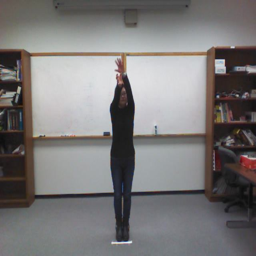

Question: What action is the person performing in this image?
Model output: The person is raising their arms above their head.
Answer: raising arms
Extracted: raising arms
Ground truth: basketball shoot
Correct: False | Format: True
------------------------------------------------------------


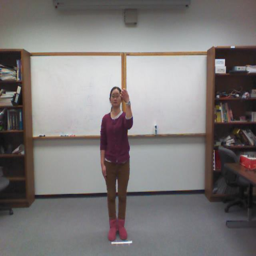

Question: What action is the person performing in this image?
Model output: The person is standing in front of a whiteboard, with one hand raised to their head and the other hand holding a small object, possibly a marker or a small item. They appear to be in a classroom or office setting.

Answer: standing
Extracted: standing
Ground truth: knock on door
Correct: False | Format: True
------------------------------------------------------------

Summary: Accuracy=0.0%, Format compliance=100.0% (2 samples)


In [ ]:
import io, requests
from PIL import Image
from IPython.display import display

# ============================================================
# ######################## CHANGE ME #########################
# ============================================================

# Replace with your own test samples, or use the defaults below.
# Each entry needs an image path (local file) or URL, a question, and ground truth.
TEST_SAMPLES = [
    {
        "image": "mmai-data/images/a7_s4_t4.jpg",
        "question": "What action is the person performing in this image?",
        "answer": "basketball shoot",
    },
    {
        "image": "mmai-data/images/a19_s2_t4.jpg",
        "question": "What action is the person performing in this image?",
        "answer": "knock on door",
    },
]

MAX_NEW_TOKENS = 256

# ============================================================
# ###################### END CHANGE ME #######################
# ============================================================

INSTRUCTION_SUFFIX = (
    "\n\nFirst, think through your reasoning step by step. "
    "Then, provide your final answer as a single word on the last line after \"Answer:\". "
    "For example:\nI can see a furry animal curled up on the couch...\nAnswer: cat"
)

def load_image(source: str) -> Image.Image:
    """Load image from a local path or URL."""
    if source.startswith("http://") or source.startswith("https://"):
        response = requests.get(source, stream=True)
        return Image.open(io.BytesIO(response.content)).convert("RGB")
    else:
        return Image.open(source).convert("RGB")

results = []

for sample in TEST_SAMPLES:
    try:
        image = load_image(sample["image"])
    except Exception as e:
        print(f"Could not load image {sample['image']}: {e}")
        continue

    messages = [
        {"role": "user", "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": sample["question"] + INSTRUCTION_SUFFIX},
        ]},
    ]

    text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[image], text=[text], return_tensors="pt", padding=True).to(ft_model.device)

    with torch.no_grad():
        output_ids = ft_model.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS, temperature=0.7, do_sample=True)

    generated = processor.decode(output_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    extracted = extract_answer(generated)

    results.append({
        "image": sample["image"],
        "question": sample["question"],
        "model_output": generated,
        "extracted_answer": extracted,
        "ground_truth": sample["answer"],
        "correct": (extracted is not None) and (extracted.lower().strip() == sample["answer"].lower().strip()),
        "has_format": extracted is not None,
    })

    display(image.resize((256, 256)))
    print(f"Question: {sample['question']}")
    print(f"Model output: {generated}")
    print(f"Extracted: {extracted}")
    print(f"Ground truth: {sample['answer']}")
    print(f"Correct: {results[-1]['correct']} | Format: {results[-1]['has_format']}")
    print("-" * 60)

n = len(results)
if n > 0:
    acc = sum(r["correct"] for r in results) / n
    fmt = sum(r["has_format"] for r in results) / n
    print(f"\nSummary: Accuracy={acc:.1%}, Format compliance={fmt:.1%} ({n} samples)")

## Problem 8.3: Reflection (5 points)

Compare the GRPO-trained model with the pre-trained base model (zero-shot) and your SFT model from HW3:
- Does the GRPO model use the `Answer:` format more consistently?

    Yes, absolutely, the GRPO-trained model always predicted the correct format , but the accuracy is lower than SFT. I think this is because our data, our images are a frame of a whole video of human high dynamic action, so a single frame somethimes cannot deliver any useful information, like when people are knocking a door, we can not get the final outcome using the initial state of their body motion. This is a disadvantage of using single modality to predict high dynamic motion, that's also why we need to use another modality to do the prediction.

- Does it show step-by-step reasoning before the answer?
    yes, it shows the whole process of reasoning, but the outcome depends on MAX_COMPLETION_LENGTH.